# RFI analysis of 1GHz to 1.5GHz

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import json
import pandas as pd
from astropy.convolution import Gaussian1DKernel, convolve


def k(x):
    return x*1000

def M(x):
    return x*1e6

def G(x):
    return x*1e9

## Load the data

In [2]:
file = '/srv/data/drao-rfi/calibrated/RFInd-calibrated-2026-02-24T10.sigmf-data'
file_2 = '/srv/data/drao-rfi/calibrated/RFInd-calibrated-2026-02-24T20.sigmf-data'
file_3 = '/srv/data/drao-rfi/calibrated/RFInd-calibrated-2024-10-08T12.sigmf-data'
meta = '/srv/data/drao-rfi/calibrated/RFInd-calibrated-2026-02-24T10.sigmf-meta'

def load_data(file):
    data = np.memmap(file, dtype='f4', mode='r')
    data = data.reshape(-1, 600000)
    data = data
    return data

# data = load_data(file)
# data_2 = load_data(file_2)
data_3 = load_data(file_3)

with open(meta) as m:
    m = json.load(m)

min_f = m['global']['antenna:low_frequency']
max_f = m['global']['antenna:high_frequency']
rate = m['global']['core:sample_rate']
period = 1/ rate
f_resolution = (max_f - min_f) / k(600)

print(f"Min Frequency: {min_f/1e6} MHz")
print(f"Max Frequency: {max_f/1e6} MHz")
print(f"Sample Rate: {rate/1e6} MHz")
print(f"Period: {period} s")
print(f"Frequency Resolution: {f_resolution/1e6} MHz")

def convert_frequency_to_index(f):
    """ Function which converts input frequency in MHz to index,
    Where index 600k = 6 GHz
    index 0 = 20 MHz

    Using inverse of
    f = i*(max_f-min_f)/k(600) + min_f
    """

    min_f = m['global']['antenna:low_frequency']
    max_f = m['global']['antenna:high_frequency']

    return int((f*1e6 - min_f)*k(600)/(max_f-min_f))

def convert_index_to_frequency(i):
    """ Function which converts input index to frequency in MHz,
    Where index 600k = 6 GHz
    index 0 = 20 MHz

    Using
    f = i*(max_f-min_f)/k(600) + min_f
    """

    min_f = m['global']['antenna:low_frequency']
    max_f = m['global']['antenna:high_frequency']   
    return (i*(max_f-min_f)/k(600) + min_f)/1e6

chord_min_f = 200
chord_max_f = 1600
CHORD_range = (convert_frequency_to_index(chord_min_f), convert_frequency_to_index(chord_max_f))

Min Frequency: 20.0 MHz
Max Frequency: 6000.0 MHz
Sample Rate: 1.3333333333333332e-06 MHz
Period: 0.75 s
Frequency Resolution: 0.009966666666666665 MHz


### The RFI Monitor cycles peridocially, cut data during the calibration cycle

In [3]:
data = data_3

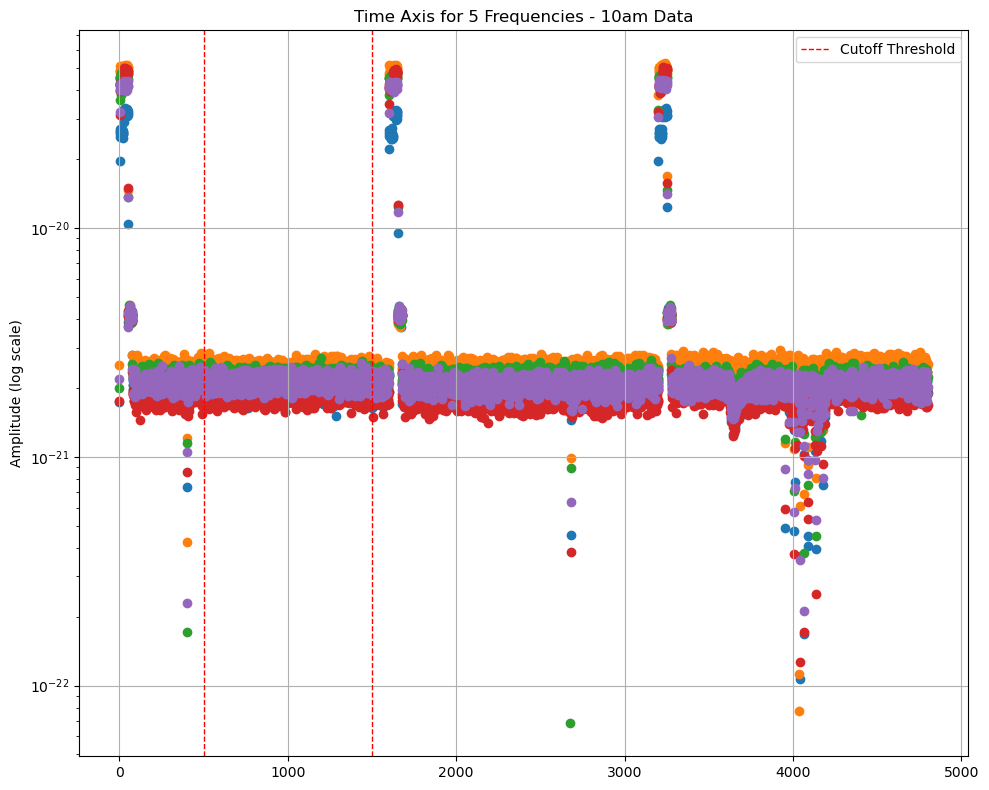

In [4]:
t1 = 0
t2 = 4800
c1 = 500
c2 = 1500

fig, ax1 = plt.subplots(figsize=(10, 8))

# Top plot - data (10am)
for i in range(100, 600, 100):
    ax1.scatter(np.arange(t1, t2), data[np.arange(t1, t2), k(i)])
ax1.axvline(x=c1, color='r', linestyle='--', linewidth=1, label='Cutoff Threshold')
ax1.axvline(x=c2, color='r', linestyle='--', linewidth=1)

ax1.set_title("Time Axis for 5 Frequencies - 10am Data")
ax1.set_yscale('log')
ax1.set_ylabel("Amplitude (log scale)")
ax1.grid(True)
ax1.legend()

plt.tight_layout()
plt.show()

def process_data(data):
    # Cutoff all values above 1 or equal to 0
    data = data[c1:c2, CHORD_range[0]:CHORD_range[1]]
    data = data* 1/np.nanmax(data)
    
    return data
# Cutoff all values above 1 or equal to 0
data_2024 = process_data(data)


## Compute Baseline across all samples using iterative smoothing

Best to run this one time since it takes a while

/tmp/ipykernel_277445/2205374572.py:26: RuntimeWarning: Mean of empty slice
  baseline, sigma = iterative_baseline(np.nanmean(data_2024, axis=0), bandwith=200, clip_sigma=5.0, n_iter=10)
/tmp/ipykernel_277445/2205374572.py:24: RuntimeWarning: divide by zero encountered in divide
  return ((M + 1) / (M - 1)) * (M * s2 / s1**2 - 1)
/tmp/ipykernel_277445/2205374572.py:24: RuntimeWarning: invalid value encountered in divide
  return ((M + 1) / (M - 1)) * (M * s2 / s1**2 - 1)
/tmp/ipykernel_277445/2205374572.py:24: RuntimeWarning: invalid value encountered in multiply
  return ((M + 1) / (M - 1)) * (M * s2 / s1**2 - 1)
/tmp/ipykernel_277445/2205374572.py:33: RuntimeWarning: Mean of empty slice
  np.linspace(chord_min_f, chord_max_f, len(np.nanmean(data_2024, axis=0))//downsample_factor+1),
/tmp/ipykernel_277445/2205374572.py:34: RuntimeWarning: Mean of empty slice
  np.nanmean(data_2024, axis=0)[0:len(np.nanmean(data_2024, axis=0)):downsample_factor],


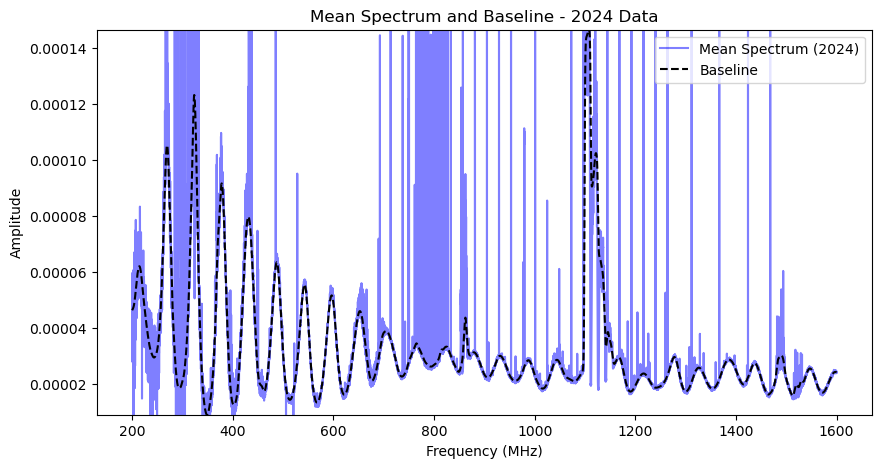

In [6]:
def iterative_baseline(y, bandwith, clip_sigma=3.0, n_iter=10):

    y = np.array(y, dtype=float)
    mask = np.isfinite(y)
    kernel = Gaussian1DKernel(stddev=bandwith)

    for _ in range(n_iter):
        masked = np.where(mask, y, np.nan)
        baseline = convolve(masked, kernel, boundary='extend',
                            nan_treatment='interpolate', normalize_kernel=True)
        residual = y - baseline
        sigma_std = np.nanstd(residual[mask])
        mask = mask & (np.abs(residual) < clip_sigma * sigma_std)

    return baseline, sigma_std

def spectral_kurtosis(P, baseline, axis=0):
    """SK per frequency bin (Nita & Gary). P must be power = |X|^2.
    With time on axis 0, returns one value per frequency bin."""
    P = (np.asarray(P, dtype=float) - baseline)**2
    M = P.shape[axis] - np.sum(np.isnan(P), axis=axis)  # Number of valid samples per frequency bin
    s1 = np.nansum(P, axis=axis)
    s2 = np.nansum(P**2, axis=axis)
    return ((M + 1) / (M - 1)) * (M * s2 / s1**2 - 1)

baseline, sigma = iterative_baseline(np.nanmean(data_2024, axis=0), bandwith=200, clip_sigma=5.0, n_iter=10)
kurtosis = spectral_kurtosis(data_2024, baseline)

downsample_factor = 10

plt.figure(figsize=(10, 5))
plt.plot(
    np.linspace(chord_min_f, chord_max_f, len(np.nanmean(data_2024, axis=0))//downsample_factor+1), 
    np.nanmean(data_2024, axis=0)[0:len(np.nanmean(data_2024, axis=0)):downsample_factor], 
    label='Mean Spectrum (2024)', 
    color='blue', alpha=0.5
)
plt.plot(
    np.linspace(chord_min_f, chord_max_f, len(baseline)//downsample_factor+1), 
    baseline[0:len(baseline):downsample_factor],
    label='Baseline', color='black', linestyle='--'
)
plt.title("Mean Spectrum and Baseline - 2024 Data")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")
plt.ylim(min(baseline), np.max(baseline))
# plt.xlim(700, 900)
plt.legend()

### Create a condensed version of the data for faster ploting

In [7]:
def compress_data(data, baseline, sigma, kurtosis, min_f, max_f, n_traces=20):

    t_samples = data.shape[0]
    f_samples = data.shape[1]
    f_range = np.linspace(min_f, max_f, f_samples)

    compressed_data = pd.DataFrame({
        "frequency": f_range,
        'baseline': baseline,
        "mean": np.nanmean(data, axis=0),
        "std": sigma,
        "kurtosis": kurtosis,
        "max": np.nanpercentile(data, 99.9, axis=0),
        "min": np.nanpercentile(data, 0.1, axis=0)
        })
    
    for i in range(n_traces):
        t_index = int((t_samples)//n_traces * i)
        trace = data[t_index, :]
        # Check that the given trace does not contain any NaN values, if it does, keep incrementing the time index until we find a trace that does not contain any NaN values
        # while np.isnan(trace).any():
        #     t_index += 1
        #     trace = data[t_index, :]
        compressed_data[f'trace_{i+1}'] = trace

    return compressed_data

compressed_data = compress_data(data_2024, baseline, sigma, kurtosis, chord_min_f, chord_max_f)
# compressed_data_8pm = compress_data(data_8pm, baseline_8pm, sigma_8pm, kurtosis_8pm, chord_min_f, chord_max_f)
compressed_data.head(2)


/tmp/ipykernel_277445/3192549533.py:10: RuntimeWarning: Mean of empty slice
  "mean": np.nanmean(data, axis=0),
/usr/local/anaconda3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


,frequency,baseline,mean,std,kurtosis,max,min,trace_1,trace_2,trace_3,...,trace_11,trace_12,trace_13,trace_14,trace_15,trace_16,trace_17,trace_18,trace_19,trace_20
0,200.000000,0.000046,0.000046,0.000002,1.961473,0.000181,-0.000068,0.000014,0.000112,0.000029,...,0.000046,0.000023,-0.000010,0.000090,0.000007,0.000021,0.000086,-5.490760e-07,0.000072,8.950283e-07
1,200.009967,0.000046,0.000048,0.000002,1.770928,0.000157,-0.000072,0.000002,0.000014,0.000031,...,0.000053,0.000049,0.000024,0.000062,0.000051,0.000148,0.000116,7.572953e-05,0.000158,1.164453e-04


/tmp/ipykernel_277445/3201090874.py:46: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax1.set_ylim(0, np.nanpercentile(plot_data['trace_1'], 99))


(<Figure size 1000x700 with 2 Axes>,
 <Axes: title={'center': '300-1500 MHz Spectrum - 2024 Data'}, ylabel='Power'>,
 <Axes: xlabel='Frequency (MHz)', ylabel='Kurtosis'>)

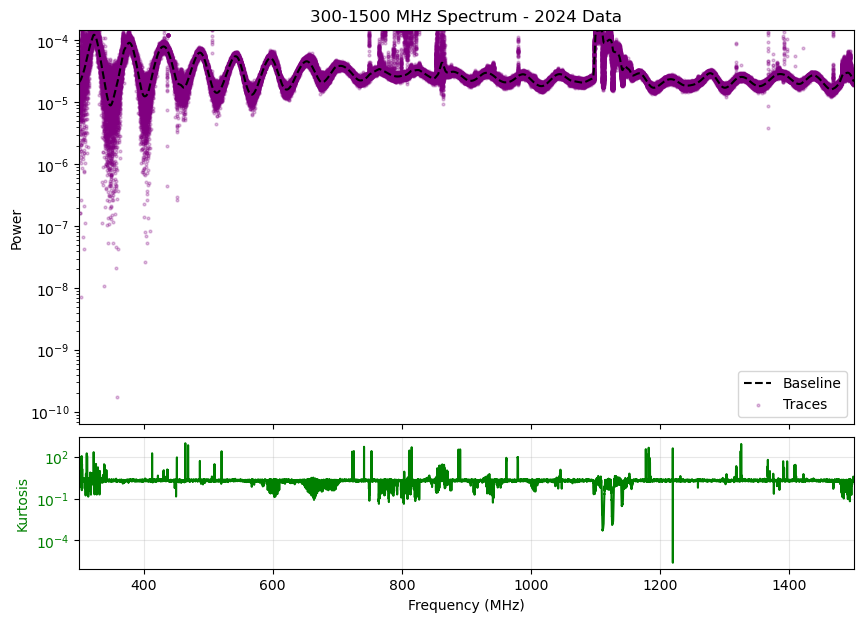

In [8]:
def plot_one(data, f_min, f_max, title=None,
             include_mean=False, include_baseline=True, include_traces=20,
             include_kurtosis=False,
             include_std=False, include_max=False, include_min=False,
             scale_y=True, downsample_factor=1):

    if include_kurtosis:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                                        gridspec_kw={'height_ratios': [3, 1]})
        plt.subplots_adjust(hspace=0.05)
    else:
        fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))

    plot_data = data[(data['frequency'] >= f_min) & (data['frequency'] <= f_max)]
    if downsample_factor > 1:
        plot_data = plot_data.iloc[::downsample_factor, :].reset_index(drop=True)
    freqs = np.linspace(f_min, f_max, len(plot_data))

    if include_mean:
        ax1.plot(freqs, plot_data['mean'], label='Mean Spectrum', color='blue', alpha=0.5)
    if include_baseline:
        ax1.plot(freqs, plot_data['baseline'], label='Baseline', color='black', linestyle='--')
    if include_std:
        ax1.plot(freqs, plot_data['baseline'] + 3*plot_data['std'],
                 label='±3σ', color='orange', linestyle='-.')
        ax1.plot(freqs, plot_data['baseline'] - 3*plot_data['std'],
                 color='orange', linestyle='-.')
    if include_max:
        ax1.plot(freqs, plot_data['max'], label='99.9th Percentile', color='red', linestyle=':')
    if include_min:
        ax1.plot(freqs, plot_data['min'], label='0.1th Percentile', color='green', linestyle=':')
    if include_traces:
        for i in range(1, include_traces + 1):
            ax1.scatter(freqs, plot_data[f'trace_{i}'],
                        color='purple', s=4, alpha=0.25,
                        label='Traces' if i == 1 else None)

    if title:
        ax1.set_title(title)
    else:
        ax1.set_title("Spectrum and Baseline")
    ax1.set_ylabel("Power")
    ax1.set_yscale('log')
    ax1.set_xlim(f_min, f_max)
    if scale_y:
        ax1.set_ylim(0, np.nanpercentile(plot_data['trace_1'], 99))
    ax1.legend()

    if include_kurtosis:
        ax2.plot(freqs, plot_data['kurtosis'], color='green', linewidth=1.5)
        ax2.set_ylabel("Kurtosis", color='green')
        ax2.tick_params(axis='y', labelcolor='green')
        ax2.set_xlabel("Frequency (MHz)")
        ax2.set_xlim(f_min, f_max)
        ax2.set_yscale('log')
        ax2.grid(alpha=0.3)
    else:
        ax1.set_xlabel("Frequency (MHz)")

    return fig, ax1, ax2 if include_kurtosis else (fig, ax1)

plot_one(compressed_data, 300, 1500, title="300-1500 MHz Spectrum - 2024 Data",
         include_mean=False, include_baseline=True, include_traces=20,
         include_kurtosis=True,
         include_std=False, include_max=False, include_min=False,
         scale_y=True, downsample_factor=10)


/tmp/ipykernel_277445/3201090874.py:46: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax1.set_ylim(0, np.nanpercentile(plot_data['trace_1'], 99))


(<Figure size 1000x700 with 2 Axes>,
 <Axes: title={'center': 'Spectrum and Baseline'}, ylabel='Power'>,
 <Axes: xlabel='Frequency (MHz)', ylabel='Kurtosis'>)

/usr/local/anaconda3/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


/usr/local/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


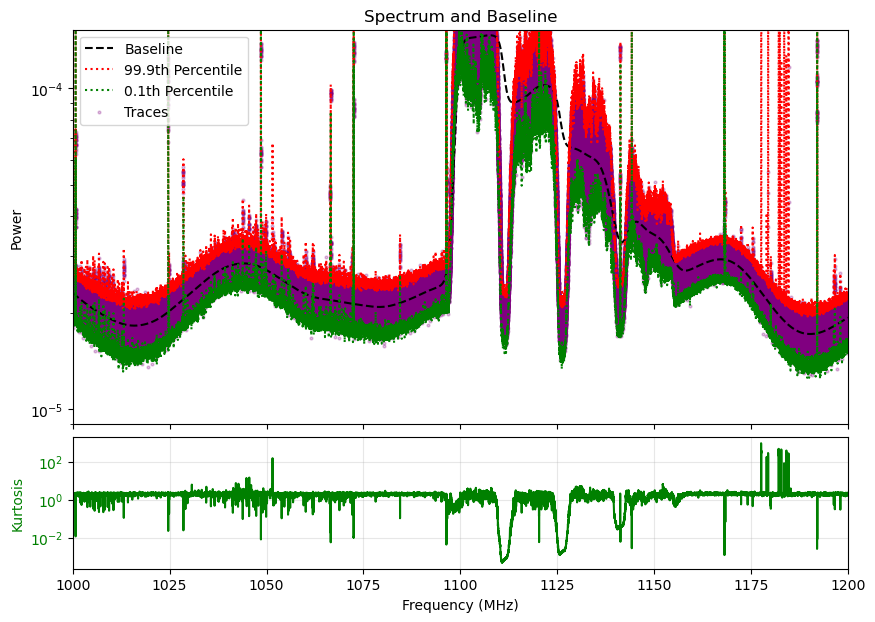

In [9]:
plot_one(compressed_data, 1000, 1200,
         include_mean=False, include_baseline=True, include_traces=20,
         include_kurtosis=True,
         include_std=False, include_max=True, include_min=True,
         scale_y=True, downsample_factor=1)

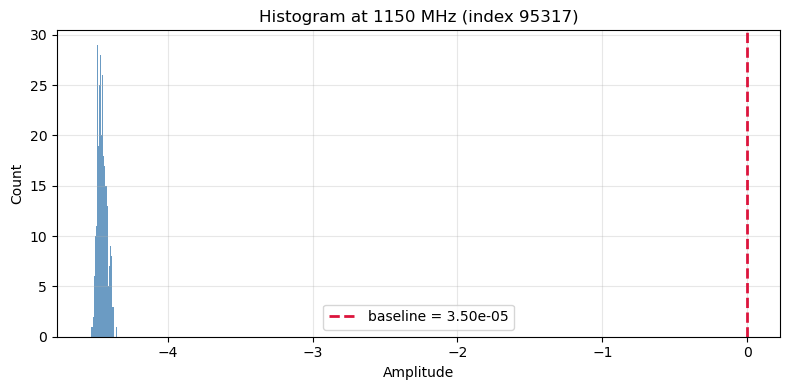

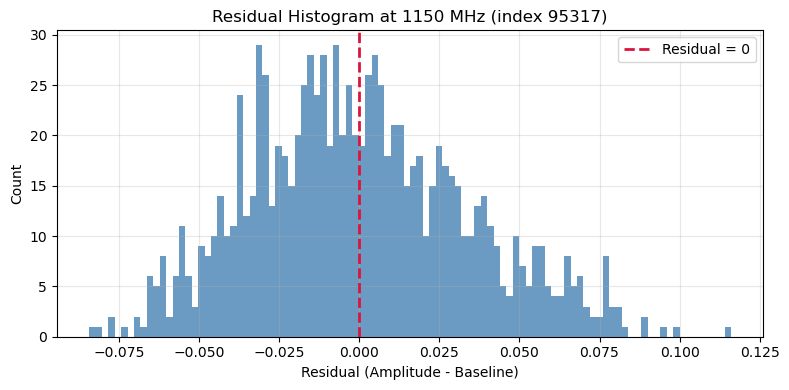

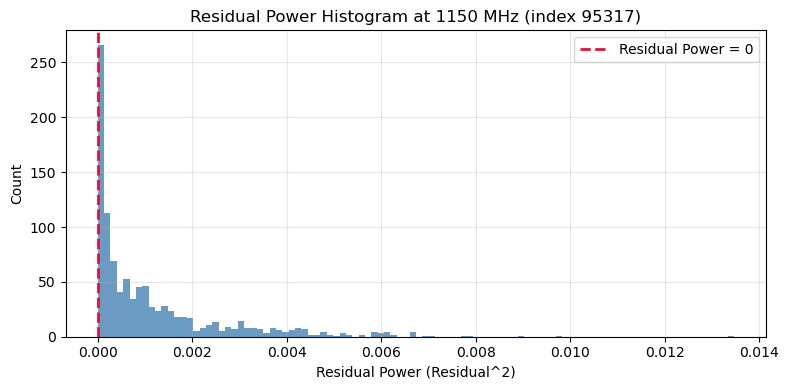

Kurtosis at 1150 MHz: 0.00


In [31]:
f = 1150
i = convert_frequency_to_index(f) - CHORD_range[0]
baseline_i = baseline[i]
col = np.log10(data_2024[:, i])
col = col[np.isfinite(col)]

plt.figure(figsize=(8, 4))
plt.hist(col, bins=100, color="steelblue", alpha=0.8)
plt.axvline(baseline_i, color="crimson", linestyle="--", linewidth=2, label=f"baseline = {baseline_i:.2e}")
plt.title(f"Histogram at {f} MHz (index {i})")
plt.xlabel("Amplitude")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

residual =col - np.nanmean(col)
plt.figure(figsize=(8, 4))
plt.hist(residual, bins=100, color="steelblue", alpha=0.8)
plt.axvline(0, color="crimson", linestyle="--", linewidth=2, label="Residual = 0")
plt.title(f"Residual Histogram at {f} MHz (index {i})")
plt.xlabel("Residual (Amplitude - Baseline)")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

residual_power = residual**2
plt.figure(figsize=(8, 4))
plt.hist(residual_power, bins=100, color="steelblue", alpha=0.8)
plt.axvline(0, color="crimson", linestyle="--", linewidth=2, label="Residual Power = 0")
plt.title(f"Residual Power Histogram at {f} MHz (index {i})")
plt.xlabel("Residual Power (Residual^2)")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

kurtosis_value = spectral_kurtosis(col, baseline_i, axis=0)
print(f"Kurtosis at {f} MHz: {kurtosis_value:.2f}")

/tmp/ipykernel_3974576/3201090874.py:46: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax1.set_ylim(0, np.nanpercentile(plot_data['trace_1'], 99))


(<Figure size 1000x700 with 2 Axes>,
 <Axes: title={'center': 'Spectrum and Baseline'}, ylabel='Power'>,
 <Axes: xlabel='Frequency (MHz)', ylabel='Kurtosis'>)

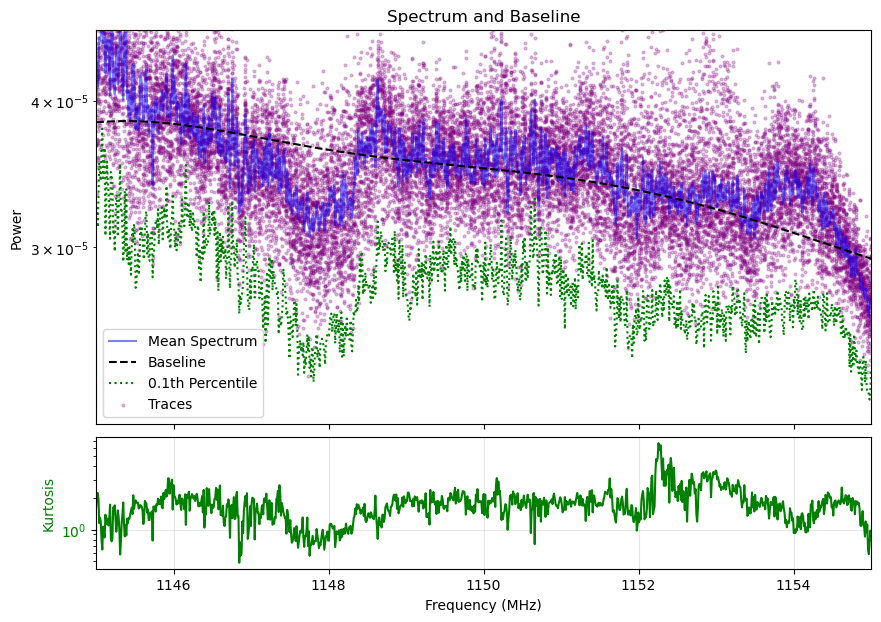

In [25]:
plot_one(compressed_data, 1145, 1155,
         include_mean=True, include_baseline=True, include_traces=20,
         include_kurtosis=True,
         include_std=False, include_max=False, include_min=True,
         scale_y=True, downsample_factor=1)

/tmp/ipykernel_3974576/3201090874.py:46: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax1.set_ylim(0, np.nanpercentile(plot_data['trace_1'], 99))


(<Figure size 1000x700 with 2 Axes>,
 <Axes: title={'center': 'Spectrum and Baseline'}, ylabel='Power'>,
 <Axes: xlabel='Frequency (MHz)', ylabel='Kurtosis'>)

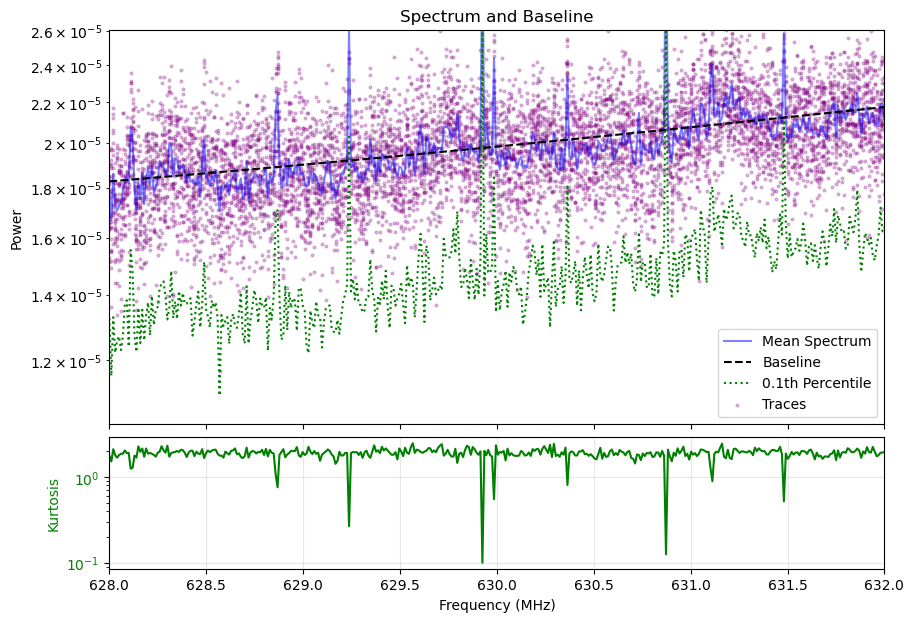

In [26]:
plot_one(compressed_data, 628, 632,
         include_mean=True, include_baseline=True, include_traces=20,
         include_kurtosis=True,
         include_std=False, include_max=False, include_min=True,
         scale_y=True, downsample_factor=1)

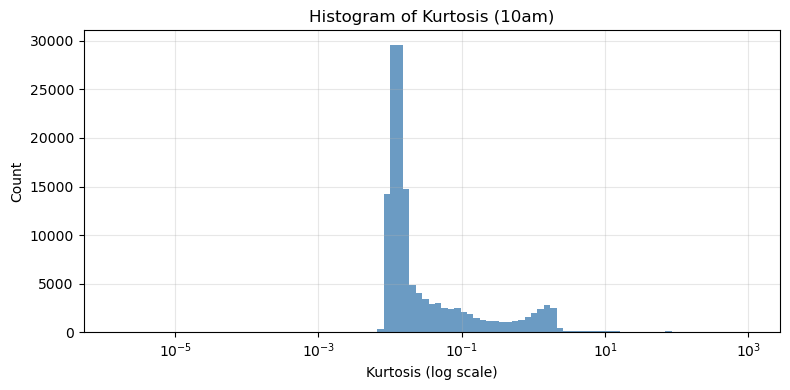

In [46]:
kurt = compressed_data["kurtosis"].dropna().to_numpy()
kurt = kurt[kurt > 0]  # required for log-x histogram

bins = np.logspace(np.log10(kurt.min()), np.log10(kurt.max()), 100)

plt.figure(figsize=(8, 4))
plt.hist(kurt, bins=bins, color="steelblue", alpha=0.8)
plt.xscale("log")
# plt.yscale("log")
plt.title("Histogram of Kurtosis (10am)")
plt.xlabel("Kurtosis (log scale)")
plt.ylabel("Count")
plt.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

In [39]:
col * 1/np.max(col)

array([0.6718597 , 0.8506906 , 0.6857367 , ..., 0.6540551 , 0.75453293,
       0.75387836], dtype=float32)

/usr/local/anaconda3/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:1983: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/tmp/ipykernel_3949653/3116598513.py:35: RuntimeWarning: divide by zero encountered in divide
  col_std_g = (col - mu_g) / sigma_g
/tmp/ipykernel_3949653/3116598513.py:35: RuntimeWarning: invalid value encountered in divide
  col_std_g = (col - mu_g) / sigma_g
/usr/local/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:118: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


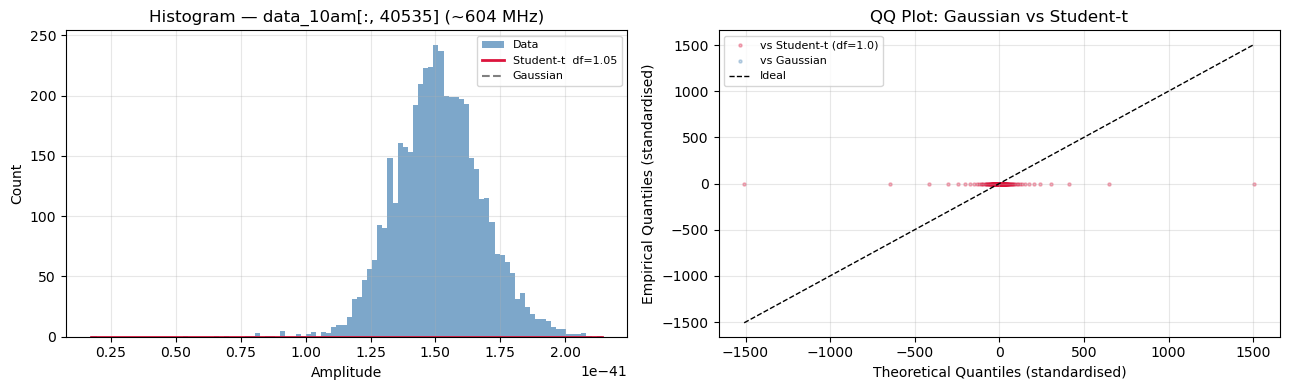

Fitted df = 1.047  (df→∞ is Gaussian, df=1 is Cauchy)


In [20]:
from scipy.stats import t as student_t, norm
from scipy.stats import probplot

i = convert_frequency_to_index(604) - CHORD_range[0]
col = data_10am[:, i]
col = col[np.isfinite(col)]

# Gaussian fit parameters
mu_g, sigma_g = np.mean(col), np.std(col)
# Fit Student's t
df_fit, mu_fit, scale_fit = student_t.fit(col, loc=mu_g, scale=sigma_g)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# --- Histogram ---
counts, bins, _ = ax1.hist(col, bins=100, color="steelblue", alpha=0.7, label="Data")
bin_width = bins[1] - bins[0]
x = np.linspace(bins[0], bins[-1], 500)
scale = len(col) * bin_width

ax1.plot(x, scale * student_t.pdf(x, df_fit, mu_fit, scale_fit),
         color="crimson", linewidth=2,
         label=f"Student-t  df={df_fit:.2f}")
ax1.plot(x, scale * norm.pdf(x, mu_g, sigma_g),
         color="gray", linewidth=1.5, linestyle="--", label="Gaussian")

ax1.set_title(f"Histogram — data_10am[:, {i}] (~604 MHz)")
ax1.set_xlabel("Amplitude")
ax1.set_ylabel("Count")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# --- Overlaid QQ plots ---
col_std_t = (col - mu_fit) / scale_fit
col_std_g = (col - mu_g) / sigma_g

(t_q, t_emp), _ = probplot(col_std_t, dist=student_t, sparams=(df_fit,), fit=True)
(g_q, g_emp), _ = probplot(col_std_g, dist=norm, fit=True)

ax2.scatter(t_q, t_emp, s=5, alpha=0.3, color="crimson", label=f"vs Student-t (df={df_fit:.1f})")
ax2.scatter(g_q, g_emp, s=5, alpha=0.3, color="steelblue", label="vs Gaussian")

lim = max(abs(t_q).max(), abs(t_emp).max(), abs(g_q).max(), abs(g_emp).max())
ax2.plot([-lim, lim], [-lim, lim], "k--", linewidth=1, label="Ideal")

ax2.set_title("QQ Plot: Gaussian vs Student-t")
ax2.set_xlabel("Theoretical Quantiles (standardized)")
ax2.set_ylabel("Empirical Quantiles (standardized)")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Fitted df = {df_fit:.3f}  (df→∞ is Gaussian, df=1 is Cauchy)")


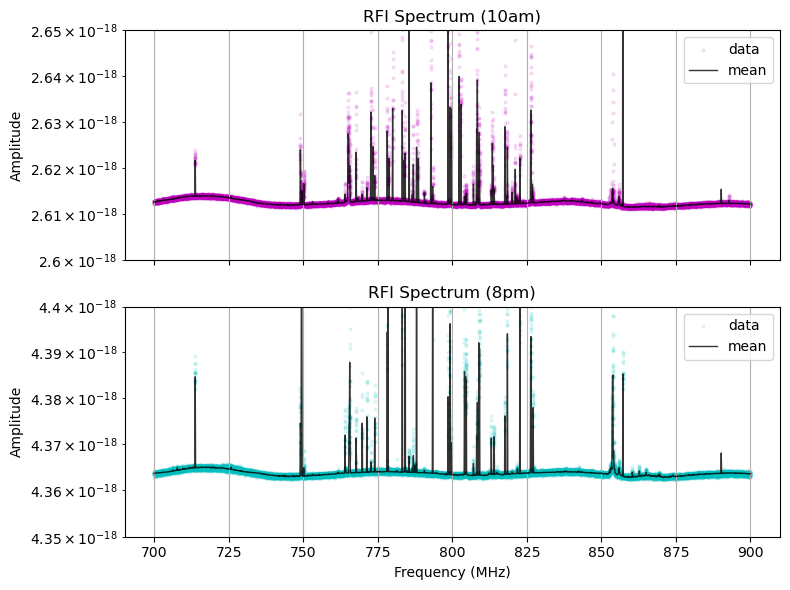

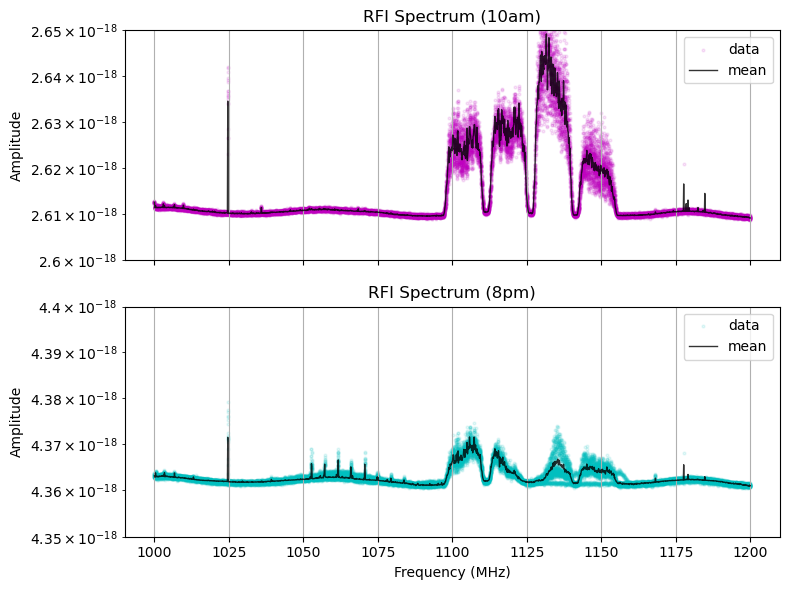

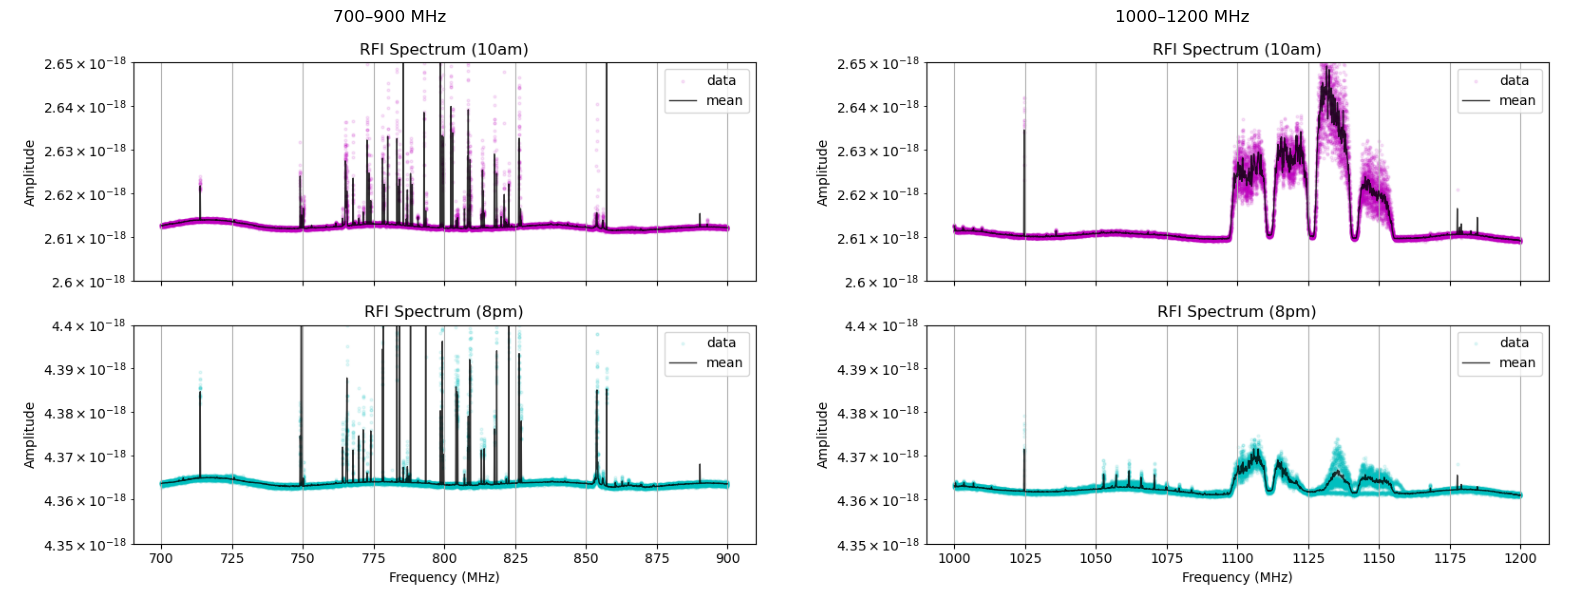

In [40]:
ranges = [(700, 900), (1000, 1200)]

# Build individual figures from your existing function
fig_list = []
for f_1, f_2 in ranges:
    fig_i, _ = plot_full_spectrum_overview(f_1, f_2, save_path=None)
    fig_list.append((fig_i, f_1, f_2))

# Create one combined figure and show each returned fig as an image
fig_side, axes_side = plt.subplots(1, len(fig_list), figsize=(16, 6))
if len(fig_list) == 1:
    axes_side = [axes_side]

for ax, (fig_i, f_1, f_2) in zip(axes_side, fig_list):
    fig_i.canvas.draw()
    w, h = fig_i.canvas.get_width_height()
    img = np.frombuffer(fig_i.canvas.buffer_rgba(), dtype=np.uint8).reshape(h, w, 4)

    ax.imshow(img)
    ax.set_title(f"{f_1}–{f_2} MHz")
    ax.axis("off")

    plt.close(fig_i)  # avoid duplicate standalone display

plt.tight_layout()
plt.savefig("../thesis/plots/rfi/side_by_side_comparison.png", dpi=300)
plt.show()


In [11]:
H_transitions = {
    "H186alpha": 1013.76766452,
    "H185alpha": 1030.25153147,
    "H184alpha": 1047.09471537,
    "H183alpha": 1064.30706038,
    "H182alpha": 1081.89873607,
    "H181alpha": 1099.88025005,
    "H180alpha": 1118.26246118,
    "H179alpha": 1137.05659327,
    "H178alpha": 1156.27424957,
    "H177alpha": 1175.92742772,
    "H176alpha": 1196.02853557,
    "H175alpha": 1216.59040757,
    "H174alpha": 1237.626322,
    "H173alpha": 1259.150019,
    "H172alpha": 1281.1757194,
    "H171alpha": 1303.71814445,
    "H170alpha": 1326.7925365,
    "H169alpha": 1350.41468066,
    "H168alpha": 1374.60092745,
    "H167alpha": 1399.36821658,
    "H166alpha": 1424.73410189,
    "H165alpha": 1450.71677746,
    "H164alpha": 1477.33510502,
}

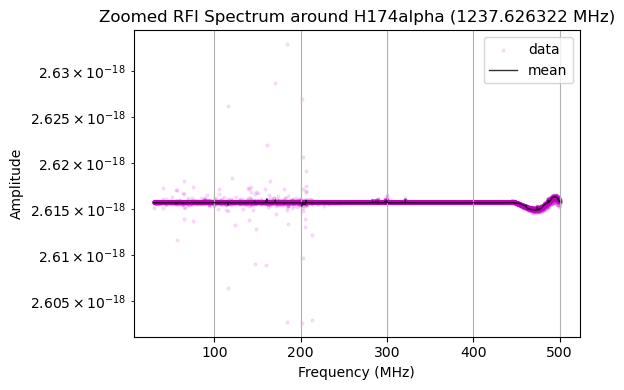

In [47]:
central_freq = H_transitions["H174alpha"]
freq_range = 10 # MHz

zoomed_data = compress_data(data_10am, 30, 500, f_samples=1000)

plt.figure(figsize=(6, 4))
for j in range(1, 20):
    plt.scatter(
        zoomed_data["frequency"],
        zoomed_data[f"trace_{j}"],
        c="m", s=4, alpha=0.1,
        label="data" if j == 1 else None
    )
plt.plot(
    zoomed_data["frequency"],
    zoomed_data["mean"],
    label="mean",
    color="black",
    linestyle="-",
    linewidth=1,
    alpha=0.8
)
plt.title(f"Zoomed RFI Spectrum around H174alpha ({central_freq} MHz)")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Amplitude")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.tight_layout()